## 시계열 분석

시간 순서대로 늘어선 값을 시계열(time series)라고 일컫는다.
시계열은 같은대상을 일정한 시간간격으로 관측해서 시간순서대로 늘어놓은 데이터를 의미
뭐때문에 하냐!? 자기상관(Autocorrelation)을 이해해야해서
모델에 적용할 수 있는것!

월별 컨테이너 물동량, 하루입항척수, 시간별 동시체류척수 같은 데이터들이 시계열 데이터라고 볼수있다.

일반 데이터같은 경우, 행의 순서를 섞어도 분석결과가 동일할 수 는 있으나 시계열에서는 순서자체가 정보이기때문에 행을 섞는 순간 지난달보다 늘었다 줄었다 하는 결론을 낼 수 없음

시계열을 다룰때 가장 먼저 정해야하는 사항이 있음
- 시점 : 각 값이 언제의 값인지
- 빈도 : 값 사이 간격이 얼마인지
- 변수 : 한 시점에 무엇을 관측할것인지

# 날짜 인덱스

인덱스를 번호로 두는 것이 아니라 데이터 내부의 시간을 인덱스로 설정하면 날짜인덱스(Datatime Index)라고 일컫는다.

`pd.date_range()`

```python
df.loc[시작시간:끝시간]

df.loc['2024-02-01':'2024-12-31']
```

## 빈도, asfreq
시점 사이의 간격을 빈도(Frequency)라고 말함. > `index.freq`로 빈도를 확인 가능.
`asfreq()` 를 이용해서도 빈도를 구할 수 있는데, 중간에 빠진 달이 있으면 해당 월의 행을 새로 만들고 결측치(NaN)로 채움.

## long, wide 형식

같은 데이터라도 표의 모양이 다를 수 있음.
long : 한 행에 날짜, 구분, 값을 하나씩 적어서 길게 늘어지는 모양,
wide : 날짜 하나를 한 행으로 두고 구분별 값을 옆으로 나란히 늘어놓은 모양

시계열 분석에서는 날짜가 인덱스고 변수가 열인 wide 형식이 계산시 유리하다.
long형식을 wide형식으로 변경할때는 pivot(index=날짜열, columns=구분열, values=값)을 사용한다.
반대로 wide형식을 long형식으로 변경할때는 melt()를 사용한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

In [6]:
long_df = pd.DataFrame({
    'date': ['2024-01', '2024-01', '2024-02', '2024-02', ],
    '구분':['수출','수입','수출','수입',],
    '물동량':[458_000,428_000,422_000,401_000,]
})

long_df

,date,구분,물동량
0,2024-01,수출,458000
1,2024-01,수입,428000
2,2024-02,수출,422000
3,2024-02,수입,401000


In [4]:
wide_df = long_df.pivot(index='date',columns='구분',values='물동량')

wide_df

구분,수입,수출
date,,
2024-01,428000,458000
2024-02,401000,422000


## 변화율

시계열데이터는 값 그 자체를 사용하기보다는 변화율을 사용한다.
ex) 3월 물동량 214만TEU, 전년대비 3.2%증가 라는 문구에서 후자가 변화에 대한 상황을 더 식별하기 용이함.

무엇과 비교하느냐에 따라 변화율의 뜻이 달라짐.
비교대상이 다른 두가지 증감률과 기간을 바꿔 합치는 리샘플링에 대해 살펴보자.

- 전월대비 증감율 : 최근에 방향이 바뀌었는가 >> `pct_change()`
- 전년 동월대비 증감율 : 계절을 빼고 봐도 늘었는가 >> `pct_change(12)`
- 연간 합계 증감율 : 한해 실적이 늘었는가 >> `resample('YS').sum()` 한 다음에 `pct_change()`

### 전월 대비 증감율

전월대비증감율은 이번달 값을 바로 앞 달과 비교한 변화율이다.
장점 : 가장 최근의 방향전화을 빨리 알아차릴수있다.
단점 : 계절의 영향이 그대로 섞인다.

ex)설날

- 전월대비증감율 = (이번달값 - 지난달값) / 지난달값 * 100

### 전년 동월대비 증감률 (Year over Year, YoY)

월별 물동량을 바로 앞달과 비교하면 계절의 영향이 포함될 수 있기 때문에
연별로 같은 달끼리 비교하는 방법을 사용할 수 도 있다.
ex) 올해 2월과 작년 2월을 비교하면 날짜 수와 계절도 같기 때문에 계절효과같은 내용들이 상당히 소거될 수 있음.

이렇게 전년도의 같은 달처럼 같은 달끼리 비교하는 방식을 전년 동월대비 증감률이라고 함.  `pct_change(12)`, `shift(12)`로 확인 가능

또한 전년 동월대비 비교도 문제가 있을 수 있는데, 대한민국의 경우, 음력에 따라 양력의 쉬는날이 바뀌기 때문.
(이때는 1~2월 값 합쳐서 보면 어느정도 해소 가능하나 월별 비교가 어려움)
또한 처음 12개월은 비교할 수 없음.

- 전년 동월대비 증감율 = (올해 이번달 값 - 작년 같은달 값) / 작년 같은달 값 * 100

## 리샘플링(Resampling)

월별 값을 연도별 합계로 바꾸거나 시간별 값을 일별 평균값으로 바꾸는 것은 시계열의 빈도를 바꾸는 것이다.
이처럼 시계열의 빈도를 바꾸어서 다시 집계하는 것을 리샘플링이라고 한다.

`groupby`은 같은 그룹끼리 묶는 것이었다면, `resample`은 같은 기간끼리 묶는 것.

`resample('YS')` : YS(Year Start)


# 시계열 구성요소

부산항 월별 물동량 그래프를 본다고 가정하면, 세가지 정도의 움직임을 포착할 수 있음.

장기간에 걸쳐 꾸준하게 올라가는 **흐름**, 2월에 내려갔다가 3월에 올라가는 것과 같은 반복되는 **패턴**, 어느 규칙으로도 설명이 어려운 들쭉날쭉한 **변동**이 있다.

- 추세 (Trend) : 오랜 기간에 걸친 방향
- 계절성 (Seasonality) : 정해진 주기로 반복되는 패턴
- 불규칙 변동 (Residual, Irregular) : 추세계절성으로 설명되지않는 나머지

## 자기상관(Autocorrelation)

계절성이 있는지를 눈으로만 판단하면 사람마다 결론이 다름.
이때 사용하는 도구가 자기상관이다!
시계열을 일정 칸수만큼 밀어놓은 자기자신과의 상관계수를 의미한다.

밀어놓은 칸수를 시차(Lag)라고 하며, 시차 12의 자기상관은 올해 각 달의 값과 작년 같은 달의 값이 얼마나 비슷하게 움직이는 가를 의미하고 -1,1 사이의 숫자로 표현한다.


`s.corr(s.shift(12))` 이렇게 구할 수 있고, `statsmodels`,`acf()` (통계학 관련) 로도 구할 수 있다.

추세가 강한 시계열은 모든 시차에서 자기상관이 1에 가깝게 나온다.
꾸준히 오르는 값은 한달전, 여섯달 전에도 비슷하게 움직이기 때문
그래서 계절주기를 찾을때는 diff()로 전월과의 차이를 먼저 구해서 추세를 걷어낸 다음에 자기상관을 확인하는 것이 바람직하다.

- 시차k의 자기상관 = corr(값(t), 값(t-k))



In [9]:
# 부산항 월별 물동량

def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

df = load_dataset('물동량예측')

df

,연도,월,연월,수출입구분,수출입구분설명,물동량
0,2003,2,2003-02,OT,수출환적,161074.50
1,2003,11,2003-11,IT,수입환적,170733.50
2,2006,1,2006-01,OT,수출환적,203348.25
3,2018,1,2018-01,OO,수출,413797.75
4,2013,6,2013-06,OO,수출,389650.25
...,...,...,...,...,...,...
1371,1996,1,1996-01,OO,수출,158518.00
1372,2001,6,2001-06,OO,수출,215325.25
1373,2001,9,2001-09,OT,수출환적,127883.00
1374,2004,1,2004-01,IT,수입환적,181137.50


In [13]:
df.shape

df.columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1376 entries, 0 to 1375
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   연도       1376 non-null   int64  
 1   월        1376 non-null   int64  
 2   연월       1376 non-null   str    
 3   수출입구분    1376 non-null   str    
 4   수출입구분설명  1376 non-null   str    
 5   물동량      1376 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 64.6 KB


In [15]:
df['수출입구분'].value_counts()

ts = df.pivot(
    index='연월',
    columns='수출입구분설명',
    values='물동량'
).copy()

ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('MS')

ts

수출입구분설명,수입,수입환적,수출,수출환적
연월,,,,
1992-01-01,92005.00,NaN,104567.00,NaN
1992-02-01,91669.00,NaN,103903.00,NaN
1992-03-01,105276.00,NaN,137082.00,NaN
1992-04-01,99261.00,NaN,130353.00,NaN
1992-05-01,95773.00,NaN,126586.00,NaN
...,...,...,...,...
2024-10-01,431582.50,574791.75,469171.75,573844.75
2024-11-01,421638.75,571301.25,444568.50,560592.25
2024-12-01,461852.75,593917.50,442416.25,569233.75


In [17]:
ts = ts[['수출','수입','수출환적','수입환적']]

ts

수출입구분설명,수출,수입,수출환적,수입환적
연월,,,,
1992-01-01,104567.00,92005.00,NaN,NaN
1992-02-01,103903.00,91669.00,NaN,NaN
1992-03-01,137082.00,105276.00,NaN,NaN
1992-04-01,130353.00,99261.00,NaN,NaN
1992-05-01,126586.00,95773.00,NaN,NaN
...,...,...,...,...
2024-10-01,469171.75,431582.50,573844.75,574791.75
2024-11-01,444568.50,421638.75,560592.25,571301.25
2024-12-01,442416.25,461852.75,569233.75,593917.50


In [20]:
# 데이터 확인
print(ts.index.min(), ts.index.max(), len(ts))
print(ts.isna().sum())
print(ts['수출환적'].first_valid_index())

1992-01-01 00:00:00 2025-02-01 00:00:00 398
수출입구분설명
수출        0
수입        0
수출환적    108
수입환적    108
dtype: int64
2001-01-01 00:00:00


In [21]:
ts.sum(axis=1)
# 결측치(NaN)를 0처럼 건너뛴다.
# 따라서 2001-01-01 부터는 물동량이 엄청나게 증가한 것처럼 보인다.


연월
1992-01-01     196572.00
1992-02-01     195572.00
1992-03-01     242358.00
1992-04-01     229614.00
1992-05-01     222359.00
                 ...    
2024-10-01    2049390.75
2024-11-01    1998100.75
2024-12-01    2067420.25
2025-01-01    2126084.75
2025-02-01    1963543.50
Freq: MS, Length: 398, dtype: float64

In [28]:
ts.loc['2000-06':'2001-06']  # 2001년 이전에는 수출/수입에 환적 물량이 포함된 것으로 추정됨

total = ts.sum(axis=1, min_count=4)
total = total.loc['2001-01':]
total

연월
2001-01-01     629545.00
2001-02-01     578213.75
2001-03-01     716271.25
2001-04-01     681030.50
2001-05-01     668563.75
                 ...    
2024-10-01    2049390.75
2024-11-01    1998100.75
2024-12-01    2067420.25
2025-01-01    2126084.75
2025-02-01    1963543.50
Freq: MS, Length: 290, dtype: float64

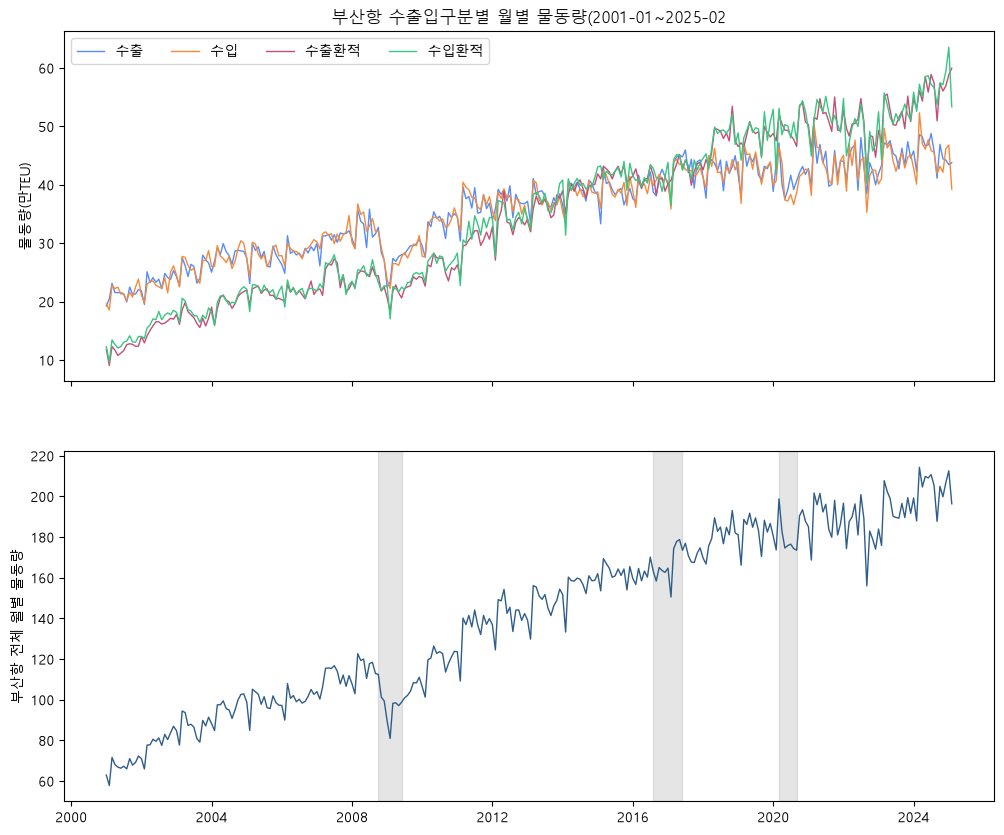

In [43]:
# 추세 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
fig, axes = plt.subplots(2,1,figsize=(12,10),sharex=True)

for col in ts.columns :
    axes[0].plot(ts.loc['2001':,col]/10_000,label=col, linewidth=1)

axes[0].set_ylabel('물동량(만TEU)')
axes[0].set_title('부산항 수출입구분별 월별 물동량(2001-01~2025-02')
axes[0].legend(ncol=4)

axes[1].plot(total/10000, color='#2f5d8a',linewidth=1)
# axes[1].legend(ncol=4)

for start, end, label in [
    ('2008-10','2009-06','금융위기'),
    ('2016-08','2017-06','한진해운 파산'),
    ('2020-03','2020-09','코로나')
] :
    axes[1].axvspan(pd.Timestamp(start),pd.Timestamp(end),color='gray',alpha=0.2) # 그래프에 구간 설정해주는것!
    # axes[1].text(pd.Timestamp(start),100,fontsize=9,va='top')

axes[1].set_ylabel('물동량(만TEU)')
axes[1].set_ylabel('부산항 전체 월별 물동량')


plt.show()

In [46]:
growth = pd.DataFrame({
    '물동량':total,
    '전월대비':total.pct_change()*100,
    '전년동월대비':total.pct_change(12)*100
})

growth.loc['2024-12':].round(2)

,물동량,전월대비,전년동월대비
연월,,,
2024-12-01,2067420.25,3.47,7.87
2025-01-01,2126084.75,2.84,6.71
2025-02-01,1963543.50,-7.65,4.48


In [49]:
months_per_year = total.resample('YS').count()
annual = total.resample('YS').sum()[months_per_year==12]

annual_growth = annual.pct_change()*100

annual_growth

연월
2001-01-01          NaN
2002-01-01    17.110370
2003-01-01    10.095680
2004-01-01    10.397445
2005-01-01     3.068810
2006-01-01     1.652514
2007-01-01    10.156327
2008-01-01     1.442411
2009-01-01   -10.945557
2010-01-01    18.479741
2011-01-01    14.021942
2012-01-01     5.321137
2013-01-01     3.754046
2014-01-01     5.638240
2015-01-01     4.203979
2016-01-01    -0.063863
2017-01-01     5.330841
2018-01-01     5.704746
2019-01-01     1.520707
2020-01-01    -0.763938
2021-01-01     4.042041
2022-01-01    -2.765488
2023-01-01     4.870478
2024-01-01     5.392323
Freq: YS-JAN, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_9348\3768096085.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\work\exp_0928\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\work\exp_0928\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


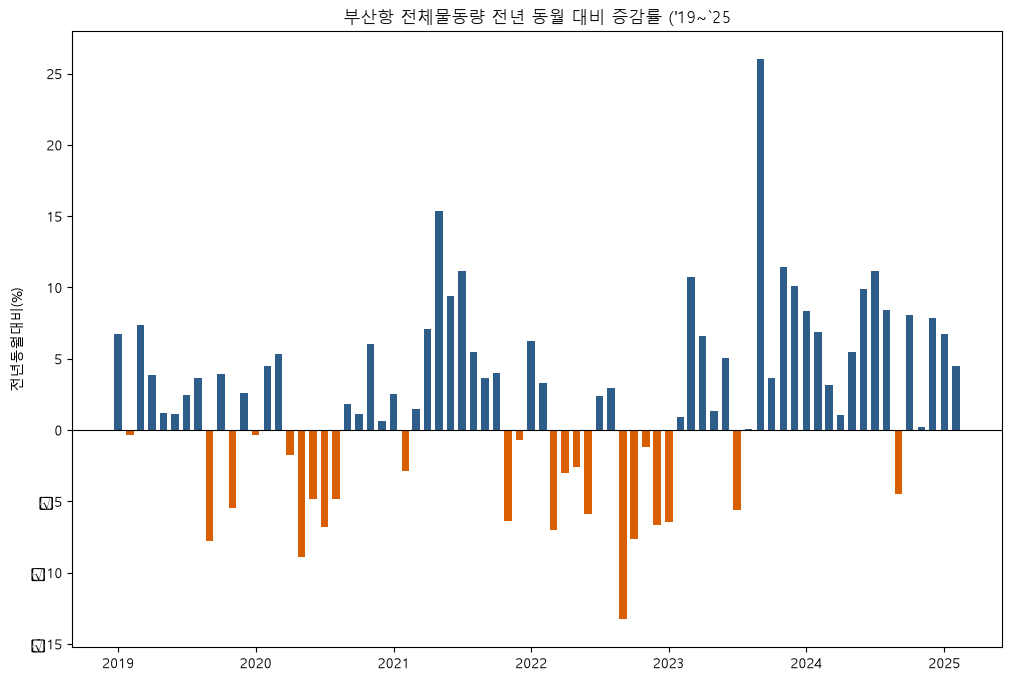

In [54]:
recent = growth.loc['2019':,'전년동월대비']

fig, ax = plt.subplots(figsize=(12,8))

colors=[ '#2f5d8a' if v>=0 else '#d95f02' for v in recent ]

ax.bar(recent.index, recent, width=20, color=colors)
ax.axhline(0,color='black',linewidth=0.8)

ax.set_ylabel('전년동월대비(%)')
ax.set_title("부산항 전체물동량 전년 동월 대비 증감률 ('19~`25")

fig.show()